# Mean Shift
Mean Shift ищет моды плотности, сдвигая точки к максимумам ядровой оценки плотности. Итерация сдвига: $x^{(t+1)} = \frac{\sum_i K\left(\frac{||x^{(t)}-x_i||^2}{h^2}\right) x_i}{\sum_i K\left(\frac{||x^{(t)}-x_i||^2}{h^2}\right)}$, где $K$ — ядро, $h$ — ширина окна. Точки, сходящиеся к одному максимуму, образуют кластер. Число кластеров определяется автоматически.


## Используемые библиотеки
Используем `numpy`, `seaborn`, `matplotlib`. Из `sklearn` — реальный датасет `load_iris`, `StandardScaler`, `PCA`, `MeanShift`, `estimate_bandwidth`, `silhouette_score`, `adjusted_rand_score`.


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, adjusted_rand_score


In [2]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120
SECONDARY_COLOR = "#ff7f0e"
HEATMAP_CMAP = "coolwarm"


## Датасет: описание и частичная распечатка
Используем реальный датасет **Iris** из `sklearn`: 150 цветков трёх видов с четырьмя числовыми признаками. Это удобный реальный пример для Mean Shift: данные компактные, быстро обрабатываются и при этом не идеально разделимы, так что автоматический поиск числа кластеров действительно имеет смысл.


In [3]:
iris = load_iris(as_frame=True)
data = iris.frame
print(f"Размерность: {data.shape}")
data.head()


Размерность: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Предварительная обработка
Отделяем признаки от целевой переменной и стандартизируем данные. Ширина окна `bandwidth` в Mean Shift задаётся в пространстве признаков, поэтому масштаб напрямую влияет на результат. Для визуализации дополнительно строим двумерную PCA-проекцию.


In [4]:
features = data.drop(columns=["target"])
target = data["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X_scaled)


## Тепловая карта корреляций
У Iris признаки частично коррелируют, особенно параметры лепестка. Это значит, что плотность в пространстве признаков не является сферической, и Mean Shift ищет моды уже в более реалистичной геометрии данных.


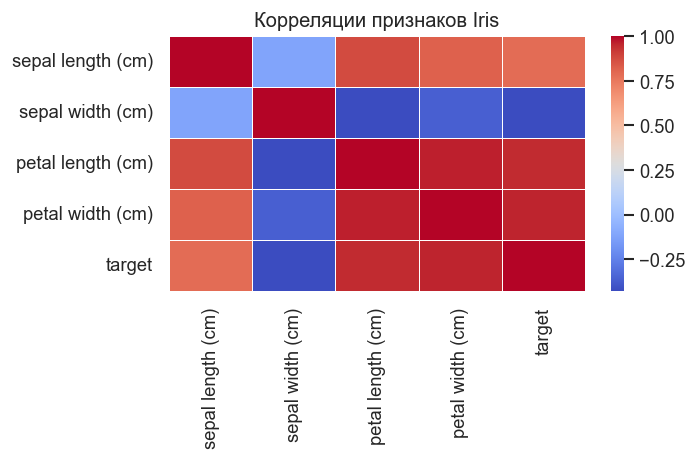

In [5]:
plt.figure(figsize=(6, 4))
correlation = data.corr()
sns.heatmap(correlation, annot=False, cmap=HEATMAP_CMAP, linewidths=0.5)
plt.title("Корреляции признаков Iris")
plt.tight_layout()
plt.show()


## Обучение модели
Используем `estimate_bandwidth(X_scaled, quantile=0.2)`, чтобы автоматически оценить разумную ширину окна по расстояниям между объектами. `bin_seeding=True` ускоряет алгоритм, особенно на более плотных данных.


In [6]:
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2)
model = MeanShift(bandwidth=bandwidth, bin_seeding=True)
model.fit(X_scaled)


,bandwidth,np.float64(1.207017869625092)
,seeds,None
,bin_seeding,True
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300


## Прогнозы модели
Смотрим число найденных кластеров и две метрики:
- **Silhouette Score** — внутренняя оценка качества разбиения;
- **Adjusted Rand Index (ARI)** — внешняя метрика согласованности с известными видами ирисов.

Если `bandwidth` слишком мал, Mean Shift создаёт много микрокластеров; если слишком велик, сливает разные виды в один.


In [7]:
labels = model.labels_

if len(np.unique(labels)) > 1:
    score = silhouette_score(X_scaled, labels)
else:
    score = float("nan")

ari = adjusted_rand_score(target, labels)

print("Mean Shift on Iris")
print(f"Bandwidth: {bandwidth:.3f}")
print(f"Clusters: {len(np.unique(labels))}")
print(f"Silhouette: {score:.3f}")
print(f"ARI: {ari:.3f}")


Mean Shift on Iris
Bandwidth: 1.207
Clusters: 3
Silhouette: 0.433
ARI: 0.560


## Графики выходных результатов
**Scatter-график на PCA-проекции с центрами.** Цвет точки — найденный кластер, оранжевые крестики — центры мод плотности. На Iris Mean Shift обычно выделяет компактные области, близкие к естественным группам, но не обязан идеально восстановить все три вида.


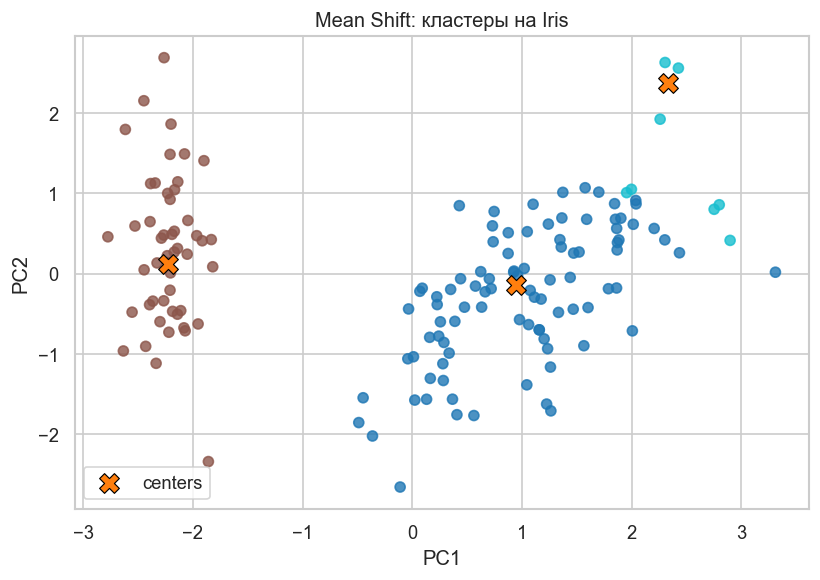

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=labels,
    cmap="tab10",
    alpha=0.8,
)
centers = model.cluster_centers_
centers_vis = pca.transform(centers)
plt.scatter(
    centers_vis[:, 0],
    centers_vis[:, 1],
    s=140,
    color=SECONDARY_COLOR,
    marker="X",
    edgecolor="black",
    linewidth=0.7,
    label="centers",
)
plt.title("Mean Shift: кластеры на Iris")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()
